In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string
import re

import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix

AxesSubplot(0.125,0.11;0.775x0.77)
     Lables                                               Data  target
1  positive  virginamerica plus youve added commercials to ...       1
3  negative  virginamerica its really aggressive to blast o...       0
4  negative  virginamerica and its a really big bad thing a...       0
5  negative  virginamerica seriously would pay 30 a flight ...       0
6  positive  virginamerica yes nearly every time i fly vx t...       1


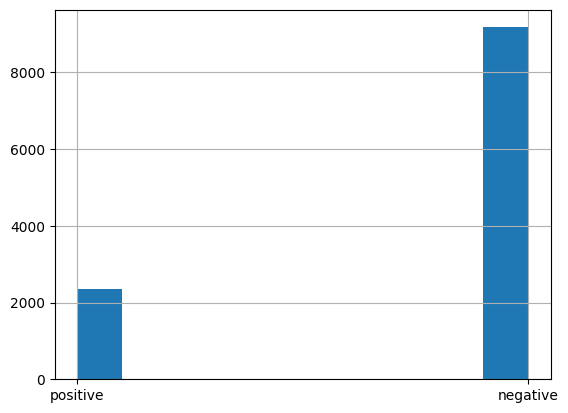

In [34]:
# Text preprocessing
df = pd.read_csv('AirlineTweet.csv', encoding=('ISO-8859-1'))
df = df[['airline_sentiment','text']]
df.columns = ['Lables', 'Data']
df['Data'] = df['Data'].str.lower().apply(lambda x: re.sub(r'[^\w\s]', '', x))
df = df[df['Lables'] != 'neutral'].copy()
print(df['Lables'].hist())
target_map = {'positive': 1, 'negative': 0}
df['target'] = df['Lables'].map(target_map)
print(df.head())

In [40]:
df_train, df_test = train_test_split(df, random_state=16)

vectorizer = TfidfVectorizer(max_features=2000)
X_train = vectorizer.fit_transform(df_train['Data'])
X_test = vectorizer.transform(df_test['Data'])

X_train = X_train.toarray()
X_test = X_test.toarray()

Y_train = df_train['target']
Y_test = df_test['target']

In [41]:
D = X_train.shape[1]
i = Input(D)
x = Dense(1)(i)
model = Model(i, x)

model.compile(
    loss = BinaryCrossentropy(from_logits=True),
    optimizer = Adam(learning_rate=0.01),
    metrics = ['accuracy']
)

In [44]:
r = model.fit(
    X_train, Y_train,
    validation_data = (X_test ,Y_test),
    epochs = 40,
    batch_size = 128
)

Epoch 1/40
68/68 [==============================] - 1s 8ms/step - loss: 0.4977 - accuracy: 0.7956 - val_loss: 0.4079 - val_accuracy: 0.7942
Epoch 2/40
68/68 [==============================] - 0s 6ms/step - loss: 0.3717 - accuracy: 0.8005 - val_loss: 0.3502 - val_accuracy: 0.8077
Epoch 3/40
68/68 [==============================] - 0s 6ms/step - loss: 0.3192 - accuracy: 0.8210 - val_loss: 0.3117 - val_accuracy: 0.8347
Epoch 4/40
68/68 [==============================] - 1s 10ms/step - loss: 0.2823 - accuracy: 0.8448 - val_loss: 0.2847 - val_accuracy: 0.8520
Epoch 5/40
68/68 [==============================] - 1s 10ms/step - loss: 0.2553 - accuracy: 0.8635 - val_loss: 0.2654 - val_accuracy: 0.8687
Epoch 6/40
68/68 [==============================] - 1s 8ms/step - loss: 0.2345 - accuracy: 0.8789 - val_loss: 0.2510 - val_accuracy: 0.8777
Epoch 7/40
68/68 [==============================] - 0s 4ms/step - loss: 0.2181 - accuracy: 0.8923 - val_loss: 0.2398 - val_accuracy: 0.8874
Epoch 8/40
68/68 [

In [46]:
p_train = ((model.predict(X_train)>0)*1.0).flatten()
p_test = ((model.predict(X_test)>0)*1.0).flatten()
cm_train = confusion_matrix(Y_train, p_train, normalize='true')
print('train confusion matrix\n', cm_train)
cm_test = confusion_matrix(Y_test, p_test, normalize='true')
print('test confusion matrix\n', cm_test)

91/91 [==============================] - 0s 2ms/step
train confusion matrix
 [[0.988237   0.011763  ]
 [0.09440362 0.90559638]]
test confusion matrix
 [[0.96422339 0.03577661]
 [0.24074074 0.75925926]]


In [47]:
model.layers[1].get_weights()

[array([[-1.9941169e+00],
        [-8.6055398e-01],
        [-1.9626992e-03],
        ...,
        [ 3.8943915e+00],
        [-6.8382949e-02],
        [ 1.5734909e+00]], dtype=float32),
 array([-0.11536127], dtype=float32)]